# Customer Churn Prediction Using Machine Learning

Complete solution for the IBM Telco Customer Churn Dataset.
Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn


In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


## Task 1 & 2 - Load Dataset

In [6]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Task 3 - Exploratory Data Analysis

In [7]:

print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)
print("\nStatistical Summary:")
display(df.describe(include='all'))


Dataset Shape: (7043, 21)

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


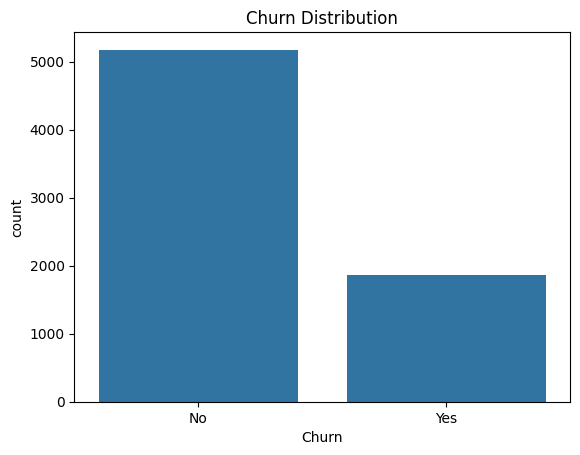

In [8]:

sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()


## Task 4 - Data Preprocessing

In [9]:

df.drop_duplicates(inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

customerID = None
if 'customerID' in df.columns:
    customerID = df['customerID']
    df = df.drop('customerID', axis=1)

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(X.head())


     gender  SeniorCitizen   Partner  Dependents    tenure  PhoneService  \
0 -1.009559      -0.439916  1.034530   -0.654012 -1.277445     -3.054010   
1  0.990532      -0.439916 -0.966622   -0.654012  0.066327      0.327438   
2  0.990532      -0.439916 -0.966622   -0.654012 -1.236724      0.327438   
3  0.990532      -0.439916 -0.966622   -0.654012  0.514251     -3.054010   
4 -1.009559      -0.439916 -0.966622   -0.654012 -1.236724      0.327438   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0       0.062723        -1.183234       -0.918838      1.242550   
1      -0.991588        -1.183234        1.407321     -1.029919   
2      -0.991588        -1.183234        1.407321      1.242550   
3       0.062723        -1.183234        1.407321     -1.029919   
4      -0.991588         0.172250       -0.918838     -1.029919   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0         -1.027910    -0.925262    -1.113495        -1.121405 -

C:\Users\Jesan N J\AppData\Local\Temp\ipykernel_37924\1414666260.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


## Task 5 - Train Test Split

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(5634, 19) (1409, 19)


## Task 6 & 7 - Train and Evaluate Models


Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



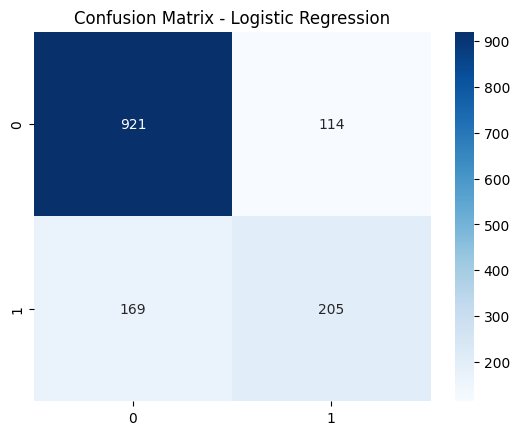


Decision Tree
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.49      0.52      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409



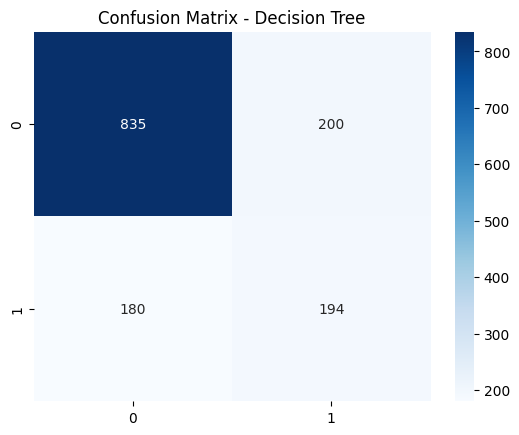


Random Forest
              precision    recall  f1-score   support

           0       0.84      0.90      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



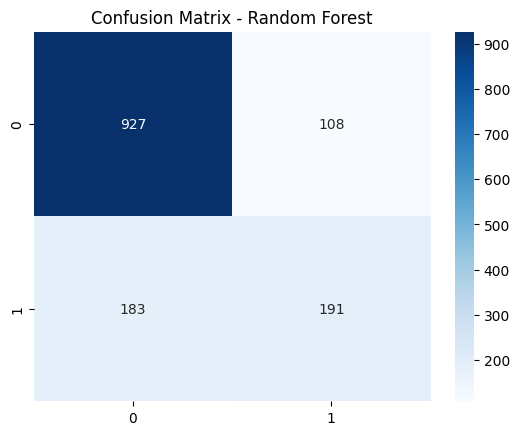


SVM
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



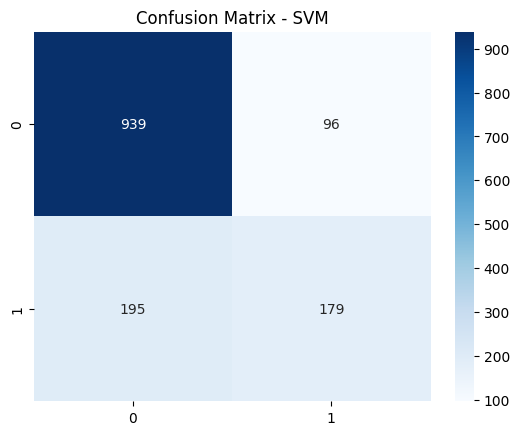


Gradient Boosting
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



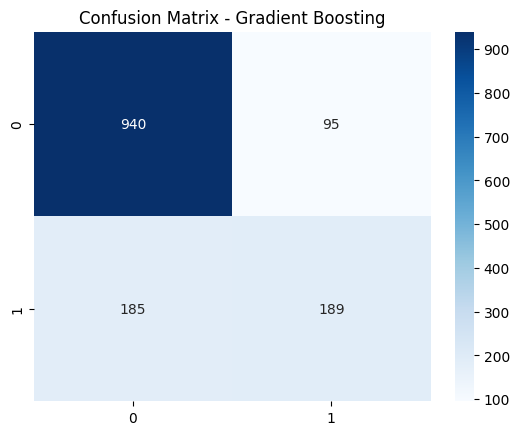

In [11]:

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc])

    print("\n", "="*60)
    print(name)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()


## Task 8 - Comparison Table

In [12]:

comparison_df = pd.DataFrame(
    results,
    columns=['Algorithm','Accuracy','Precision','Recall','F1-score','ROC-AUC']
)

comparison_df = comparison_df.sort_values(by='ROC-AUC', ascending=False)
display(comparison_df)


,Algorithm,Accuracy,Precision,Recall,F1-score,ROC-AUC
4,Gradient Boosting,0.801278,0.665493,0.505348,0.574468,0.844869
0,Logistic Regression,0.799148,0.642633,0.548128,0.591631,0.840239
2,Random Forest,0.793471,0.638796,0.510695,0.567608,0.821818
3,SVM,0.793471,0.650909,0.478610,0.551618,0.790907
1,Decision Tree,0.730305,0.492386,0.518717,0.505208,0.662526


## Task 9 - Best Model

In [13]:

best_model = comparison_df.iloc[0]
print("Best Performing Model:")
print(best_model)


Best Performing Model:
Algorithm    Gradient Boosting
Accuracy              0.801278
Precision             0.665493
Recall                0.505348
F1-score              0.574468
ROC-AUC               0.844869
Name: 4, dtype: object


## Task 10 - Feature Importance Analysis

,Feature,Importance
18,TotalCharges,0.186841
17,MonthlyCharges,0.179192
4,tenure,0.154338
14,Contract,0.079631
16,PaymentMethod,0.050095
8,OnlineSecurity,0.049580
11,TechSupport,0.043603
0,gender,0.027892
7,InternetService,0.027789
9,OnlineBackup,0.027075


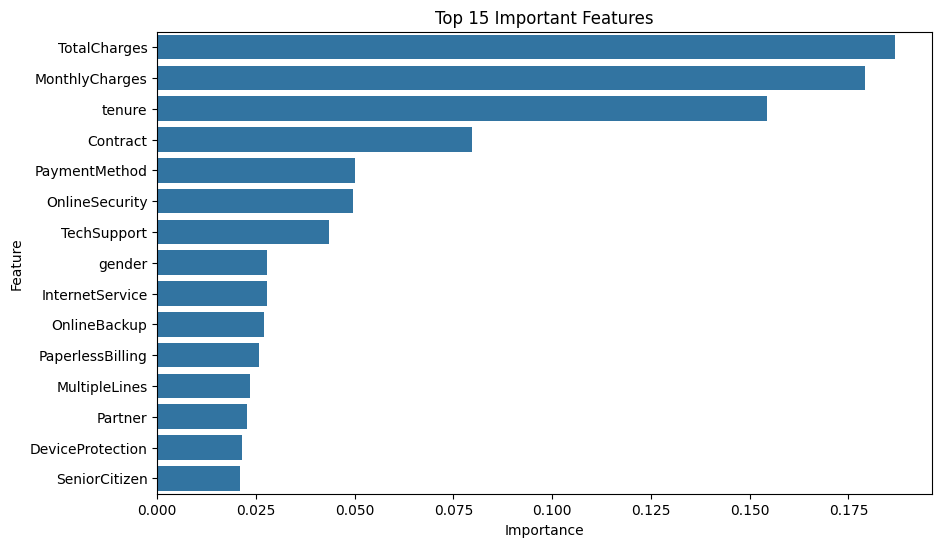

In [14]:

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

display(importance.head(15))

plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(15), x='Importance', y='Feature')
plt.title('Top 15 Important Features')
plt.show()



# Discussion Questions (Answers)

1. Customer churn prediction helps retain customers and increase revenue.
2. Contract type, tenure, monthly charges and support services often influence churn.
3. Preprocessing improves data quality and model performance.
4. Machine learning models require numerical inputs.
5. Train-test split evaluates generalization on unseen data.
6. ROC-AUC and F1-score are useful for imbalanced churn datasets.
7. Random Forest reduces overfitting by combining multiple trees.
8. Overfitting occurs when a model memorizes training data; pruning, regularization and cross-validation help.
9. Feature importance identifies factors affecting churn and supports business decisions.
10. Offer retention plans, discounts, improved support, and targeted promotions.
